# Training-Time Ensemble with JS Divergence + Margin + Variance

This notebook loads **pre-computed `.npy` probability files** from a saved cache folder.
No base models are loaded or run. All inference is done at the meta-learner level only.

## What's new vs. the entropy baseline

Instead of a flat entropy feature, we now build a **richer 21-dimensional feature vector**:

| Group | # Features | Description |
|-------|-----------|-------------|
| Raw probs | 9 | 3 models × 3 class probabilities |
| JS Divergence | 3 | Pairwise JS divergence between model distributions (BERT–mDeBERTa, BERT–Qwen, mDeBERTa–Qwen) |
| Margin | 3 | max_prob − second_max_prob per model (confidence of top prediction) |
| Variance | 3 | Per-class variance of probabilities across the 3 models |
| Mean prob | 3 | Per-class mean probability across the 3 models |

**Total: 21 features**

JS Divergence captures *disagreement* between model pairs — high JS means the models
disagree, which is a signal the ensemble should weight more carefully.
Margin captures *confidence* — a high-margin model is more certain of its top prediction.
Variance captures *spread* across models for each class.

## Models
Only 3 base models are used: **BERT**, **mDeBERTa**, **Qwen**.
(Gemma has been removed.)

## Cache folder layout expected
```
stacking_cache_train_split_16feat_entropy/
  snli_tr_1_1__train__bert_probs.npy
  snli_tr_1_1__train__mdeberta_probs.npy
  snli_tr_1_1__train__qwen_probs.npy
  ...  (one file per config × split × model)
```

## Upload and Unzip Cache

Run these cells first if you need to upload your cache zip to Colab.

In [3]:
from google.colab import files

# Upload files from your local system
uploaded = files.upload()

for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))

Saving stacking_cache_train_split_16feat_entropy.zip to stacking_cache_train_split_16feat_entropy.zip
User uploaded file "stacking_cache_train_split_16feat_entropy.zip" with length 38987807 bytes


In [9]:
# Replace with the actual name of your uploaded zip file.
# The files will be extracted to /content/
!unzip -q /content/stacking_cache_train_split_16feat_entropy.zip -d /content/
print("Unzip complete. Contents:")
#!ls /content/stacking_cache_train_split_16feat_entropy/ | head -20


replace /content/snli_tr_1_1__test__mdeberta_probs.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: error:  invalid response [{ENTER}]
replace /content/snli_tr_1_1__test__mdeberta_probs.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: Unzip complete. Contents:


## Imports

In [5]:
import os
import random
from collections import Counter
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

from datasets import load_dataset
from IPython.display import display

from scipy.stats import entropy as scipy_entropy

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

## Global Configuration

- **MODEL_ORDER**: 3 models only — Gemma removed.
- **FEATURE_DIM**: 21 (9 probs + 3 JS div + 3 margin + 3 variance + 3 mean prob).
- All feature groups can be toggled via `build_X()` flags for ablation studies.

In [12]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ── 3 base models only (Gemma removed) ──
MODEL_ORDER  = ["bert", "mdeberta", "qwen"]
NUM_MODELS   = len(MODEL_ORDER)  # 3

DATASET_NAME = "yilmazzey/sdp2-nli"
CONFIGS      = ["snli_tr_1_1", "multinli_tr_1_1", "trglue_mnli"]
LABEL_MAP    = {0: "entailment", 1: "neutral", 2: "contradiction"}
LABEL_NAMES  = [LABEL_MAP[i] for i in range(3)]
NUM_LABELS   = 3

EVAL_SPLITS = {
    "snli_tr_1_1":     ["test"],
    "multinli_tr_1_1": ["validation_matched", "validation_mismatched"],
    "trglue_mnli":     ["test_matched", "test_mismatched"],
}

# Static ensemble weights (3 models)
STATIC_WEIGHTED_WEIGHTS = {"bert": 0.25, "mdeberta": 0.15, "qwen": 0.60}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ── Cache and artifact directories ──
CACHE_DIR    = Path("")
ARTIFACT_DIR = Path("stacking_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

assert CACHE_DIR.exists(), (
    f"Cache folder not found: {CACHE_DIR.resolve()}\n"
    "Set CACHE_DIR to the folder that contains the .npy probability files."
)
print("Cache folder:", CACHE_DIR.resolve())

# ── Training hyper-parameters ──
META_EPOCHS             = 40
EARLY_STOPPING_PATIENCE = 8
META_BATCH_SIZE         = 128
LEARNING_RATE           = 1e-3
WEIGHT_DECAY            = 1e-4

# ── Feature dimension reference ──
# Probs:    9  (3 models × 3 classes)
# JS div:   3  (3 pairs: bert-mdeberta, bert-qwen, mdeberta-qwen)
# Margin:   3  (1 per model)
# Variance: 3  (1 per class, across models)
# Mean:     3  (1 per class, across models)
# Total:   21
FEATURE_DIM = 21

# Human-readable feature names for importance plots (must match build_X column order)
FEATURE_NAMES = [
    # --- Raw probabilities (cols 0-8) ---
    "bert_p0",     "bert_p1",     "bert_p2",
    "mdeberta_p0", "mdeberta_p1", "mdeberta_p2",
    "qwen_p0",     "qwen_p1",     "qwen_p2",
    # --- JS Divergence (cols 9-11) ---
    "js_bert_mdeberta", "js_bert_qwen", "js_mdeberta_qwen",
    # --- Margin (cols 12-14) ---
    "margin_bert", "margin_mdeberta", "margin_qwen",
    # --- Per-class variance across models (cols 15-17) ---
    "var_class0", "var_class1", "var_class2",
    # --- Per-class mean across models (cols 18-20) ---
    "mean_class0", "mean_class1", "mean_class2",
]

# Column index ranges for each feature group (used by build_X and ablations)
FEAT_GROUPS = {
    "probs":    list(range(0, 9)),
    "jsdiv":    list(range(9, 12)),
    "margin":   list(range(12, 15)),
    "variance": list(range(15, 18)),
    "mean":     list(range(18, 21)),
}

print(f"\nFeature vector: {FEATURE_DIM} dimensions")
for g, cols in FEAT_GROUPS.items():
    print(f"  {g:12s}: cols {cols[0]}–{cols[-1]} ({len(cols)} features)")

Device: cuda
GPU: NVIDIA H100 80GB HBM3
Cache folder: /content

Feature vector: 21 dimensions
  probs       : cols 0–8 (9 features)
  jsdiv       : cols 9–11 (3 features)
  margin      : cols 12–14 (3 features)
  variance    : cols 15–17 (3 features)
  mean        : cols 18–20 (3 features)


## Load Labels from HuggingFace

We only need the label arrays — no base model inference.

In [20]:
# Read HF token from environment — never hard-code tokens.
hf_token = os.environ.get("HF_TOKEN", None)
if hf_token:
    from huggingface_hub import login
    login(token=hf_token)
    print("Logged in to HuggingFace.")
else:
    print("HF_TOKEN not set — assuming public dataset or already logged in.")

HF_TOKEN not set — assuming public dataset or already logged in.


In [21]:
datasets_hf = {}
for cfg in CONFIGS:
    print(f"Loading labels: {DATASET_NAME} :: {cfg}")
    datasets_hf[cfg] = load_dataset(DATASET_NAME, cfg)
    print("  splits:", list(datasets_hf[cfg].keys()))
print("Label loading complete.")

Loading labels: yilmazzey/sdp2-nli :: snli_tr_1_1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

snli_tr_1_1/train-00000-of-00001.parquet:   0%|          | 0.00/25.4M [00:00<?, ?B/s]

snli_tr_1_1/validation-00000-of-00001.pa(…):   0%|          | 0.00/558k [00:00<?, ?B/s]

...

Generating validation_matched split:   0%|          | 0/9050 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9200 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9008 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9217 [00:00<?, ? examples/s]

  splits: ['train', 'validation_matched', 'validation_mismatched', 'test_matched', 'test_mismatched']
Label loading complete.


In [22]:
from huggingface_hub import login
login(token=os.environ.get("HF_TOKEN"))

## Cache Loading Utilities

Each `.npy` file contains shape `(N, 3)` — softmax probabilities over the 3 NLI classes.
Index 0 = entailment, 1 = neutral, 2 = contradiction (consistent with HuggingFace label_map).

In [13]:
def cache_name(config: str, split: str, model_key: str) -> Path:
    """Construct the .npy file path for a given config/split/model."""
    safe_cfg = config.replace("/", "_")
    safe_sp  = split.replace("/", "_")
    return CACHE_DIR / f"{safe_cfg}__{safe_sp}__{model_key}_probs.npy"


def load_probs_from_cache(config: str, split: str) -> dict:
    """
    Load probability arrays for all 3 models from .npy cache files.

    Returns
    -------
    dict {model_key -> np.ndarray of shape (N, 3)}
        Each row sums to 1.0 (softmax probabilities).
        Column order: [p_entailment, p_neutral, p_contradiction]
        i.e. col 0 = entailment, col 1 = neutral, col 2 = contradiction.
        This matches the HuggingFace label encoding (0=entailment, 1=neutral, 2=contradiction).
    """
    probs = {}
    for model_key in MODEL_ORDER:
        p = cache_name(config, split, model_key)
        if not p.exists():
            raise FileNotFoundError(
                f"Missing cache file: {p}\n"
                f"Run the feature-extraction notebook first."
            )
        arr = np.load(p)  # shape (N, 3)
        assert arr.ndim == 2 and arr.shape[1] == 3, (
            f"{p}: expected shape (N, 3), got {arr.shape}"
        )
        probs[model_key] = arr.astype(np.float32)
    shapes = {k: v.shape for k, v in probs.items()}
    print(f"  Loaded {config}/{split} — shapes: {shapes}")
    return probs

## Feature Engineering

### Feature vector layout (21 dimensions)

```
Cols  0– 2:  bert_p0, bert_p1, bert_p2          (raw probs — entailment/neutral/contradiction)
Cols  3– 5:  mdeberta_p0, mdeberta_p1, mdeberta_p2
Cols  6– 8:  qwen_p0, qwen_p1, qwen_p2
Col   9:     JS(bert ‖ mdeberta)                 (symmetric divergence between model distributions)
Col  10:     JS(bert ‖ qwen)
Col  11:     JS(mdeberta ‖ qwen)
Col  12:     margin_bert   = max_p - second_max_p  (confidence of top prediction)
Col  13:     margin_mdeberta
Col  14:     margin_qwen
Col  15:     var_class0    (variance of entailment prob across 3 models)
Col  16:     var_class1    (variance of neutral prob across 3 models)
Col  17:     var_class2    (variance of contradiction prob across 3 models)
Col  18:     mean_class0   (mean entailment prob across 3 models)
Col  19:     mean_class1   (mean neutral prob across 3 models)
Col  20:     mean_class2   (mean contradiction prob across 3 models)
```

### Why JS Divergence over entropy?

Entropy measures a single model's uncertainty.
**JS Divergence** measures *disagreement between two models* — it is symmetric,
always finite (bounded in [0, log 2]), and equals zero iff both distributions are identical.
High JS between BERT and Qwen signals that the two models disagree, which is
informative for the meta-learner to decide whom to trust.

### Why Margin?

Margin = max_prob − second_max_prob. A model with margin ≈ 1.0 is very confident;
margin ≈ 0.0 means the top two classes are nearly tied. The meta-learner can
down-weight low-confidence models.

### Why Variance?

Per-class variance across models captures whether models *agree on the class
probability*, not just on the argmax. High variance for class 0 means models
give very different estimates for entailment.

In [14]:
def js_divergence(p: np.ndarray, q: np.ndarray) -> np.ndarray:
    """
    Jensen-Shannon Divergence between two batches of distributions.

    JS(P‖Q) = 0.5 * KL(P‖M) + 0.5 * KL(Q‖M)  where M = 0.5*(P+Q)

    Parameters
    ----------
    p, q : np.ndarray of shape (N, 3)
        Probability distributions (each row sums to ~1).

    Returns
    -------
    np.ndarray of shape (N,)
        JS divergence in nats, bounded in [0, ln(2)] ≈ [0, 0.693].
    """
    p = np.clip(p, 1e-10, 1.0)
    q = np.clip(q, 1e-10, 1.0)
    m = 0.5 * (p + q)
    # scipy_entropy computes KL(pk ‖ qk) = sum(pk * log(pk/qk)) per column
    # We pass axis=1 so it operates row-wise
    kl_pm = np.sum(p * np.log(p / m), axis=1)  # KL(P‖M)
    kl_qm = np.sum(q * np.log(q / m), axis=1)  # KL(Q‖M)
    return 0.5 * kl_pm + 0.5 * kl_qm           # shape (N,)


def compute_margin(probs: np.ndarray) -> np.ndarray:
    """
    Prediction margin: max_prob − second_max_prob.

    High margin → confident prediction.
    Low margin  → ambiguous (top two classes nearly tied).

    Parameters
    ----------
    probs : np.ndarray of shape (N, 3)

    Returns
    -------
    np.ndarray of shape (N,)
    """
    sorted_p = np.sort(probs, axis=1)[:, ::-1]  # descending, shape (N, 3)
    return sorted_p[:, 0] - sorted_p[:, 1]       # max - second_max


def build_X(
    probs_dict: dict,
    use_probs:    bool = True,
    use_jsdiv:    bool = True,
    use_margin:   bool = True,
    use_variance: bool = True,
    use_mean:     bool = True,
) -> np.ndarray:
    """
    Flexible feature builder — each group can be enabled/disabled for ablation.

    Full feature layout (21 columns when all groups enabled):
      Cols  0– 2: bert probs          (entailment, neutral, contradiction)
      Cols  3– 5: mdeberta probs
      Cols  6– 8: qwen probs
      Col   9:    JS(bert, mdeberta)  [in nats; range 0..ln(2)]
      Col  10:    JS(bert, qwen)
      Col  11:    JS(mdeberta, qwen)
      Col  12:    margin_bert         [range 0..1]
      Col  13:    margin_mdeberta
      Col  14:    margin_qwen
      Col  15:    var_class0          [variance of p_entailment across 3 models]
      Col  16:    var_class1
      Col  17:    var_class2
      Col  18:    mean_class0         [mean p_entailment across 3 models]
      Col  19:    mean_class1
      Col  20:    mean_class2

    Parameters
    ----------
    probs_dict : dict {model_key -> np.ndarray (N, 3)}
        Must contain all keys in MODEL_ORDER.
        Column order within each array: [p_entailment, p_neutral, p_contradiction].
        This matches the HuggingFace label encoding used in LABEL_MAP.

    Returns
    -------
    np.ndarray of shape (N, D) where D depends on which groups are enabled.
    """
    bert_p = probs_dict["bert"]      # (N, 3)
    mdeb_p = probs_dict["mdeberta"]  # (N, 3)
    qwen_p = probs_dict["qwen"]      # (N, 3)

    # Stack for variance / mean computation: shape (3, N, 3)
    stacked = np.stack([bert_p, mdeb_p, qwen_p], axis=0)

    parts = []

    # ── Group 1: Raw probabilities (9 features) ──
    # Each model contributes its full 3-class softmax output.
    # Col i*3 + j = probability of class j for model i.
    if use_probs:
        parts.append(bert_p)   # cols 0-2
        parts.append(mdeb_p)   # cols 3-5
        parts.append(qwen_p)   # cols 6-8

    # ── Group 2: JS Divergence between pairs (3 features) ──
    # Captures disagreement between model distributions.
    # All 3 pairs of the 3 models: C(3,2) = 3.
    if use_jsdiv:
        js_bm = js_divergence(bert_p, mdeb_p).reshape(-1, 1)  # col 9
        js_bq = js_divergence(bert_p, qwen_p).reshape(-1, 1)  # col 10
        js_mq = js_divergence(mdeb_p, qwen_p).reshape(-1, 1)  # col 11
        parts.extend([js_bm, js_bq, js_mq])

    # ── Group 3: Margin per model (3 features) ──
    # margin = max_prob - second_max_prob; higher = more confident.
    if use_margin:
        parts.append(compute_margin(bert_p).reshape(-1, 1))   # col 12
        parts.append(compute_margin(mdeb_p).reshape(-1, 1))   # col 13
        parts.append(compute_margin(qwen_p).reshape(-1, 1))   # col 14

    # ── Group 4: Per-class variance across models (3 features) ──
    # var_class_j = variance of p_j across the 3 models for each example.
    # High variance for class j → models disagree on the probability of class j.
    if use_variance:
        var_per_class = stacked.var(axis=0)  # (N, 3)
        parts.append(var_per_class)          # cols 15-17

    # ── Group 5: Per-class mean across models (3 features) ──
    # mean_class_j = ensemble average probability for class j.
    # Essentially a soft majority vote; similar to simple averaging.
    if use_mean:
        mean_per_class = stacked.mean(axis=0)  # (N, 3)
        parts.append(mean_per_class)           # cols 18-20

    assert parts, "At least one feature group must be enabled."
    return np.hstack(parts).astype(np.float32)


def get_feature_names_for_mask(
    use_probs=True, use_jsdiv=True,
    use_margin=True, use_variance=True, use_mean=True
) -> list:
    """Return the feature name list matching the same build_X flags."""
    names = []
    if use_probs:    names += FEATURE_NAMES[0:9]
    if use_jsdiv:    names += FEATURE_NAMES[9:12]
    if use_margin:   names += FEATURE_NAMES[12:15]
    if use_variance: names += FEATURE_NAMES[15:18]
    if use_mean:     names += FEATURE_NAMES[18:21]
    return names


# ── Sanity check ──
print("Feature vector with all groups enabled:")
dummy = {m: np.random.dirichlet([1, 1, 1], 10).astype(np.float32) for m in MODEL_ORDER}
X_dummy = build_X(dummy)
print(f"  Shape: {X_dummy.shape}  (expected (10, {FEATURE_DIM}))")
assert X_dummy.shape == (10, FEATURE_DIM), "FEATURE_DIM mismatch!"
print("  ✓ Feature shapes match.")
del dummy, X_dummy

Feature vector with all groups enabled:
  Shape: (10, 21)  (expected (10, 21))
  ✓ Feature shapes match.


## Static Ensemble Helpers

Baseline methods that do not require meta-learner training.

In [15]:
def weighted_static_pred(probs_dict: dict) -> np.ndarray:
    """Weighted average of softmax probabilities (3 models, hand-tuned weights)."""
    w     = np.array([STATIC_WEIGHTED_WEIGHTS[m] for m in MODEL_ORDER], dtype=np.float32)
    stack = np.stack([probs_dict[m] for m in MODEL_ORDER], axis=0)  # (3, N, 3)
    # einsum: m=model, n=sample, c=class → weighted sum over models
    return np.einsum("m,mnc->nc", w, stack).argmax(axis=1)


def majority_vote_pred(probs_dict: dict) -> np.ndarray:
    """Hard majority vote (argmax per model, then mode)."""
    votes = np.stack([probs_dict[m].argmax(1) for m in MODEL_ORDER], axis=1)  # (N, 3)
    return np.array(
        [int(Counter(row.tolist()).most_common(1)[0][0]) for row in votes],
        dtype=np.int64,
    )

## Meta-Learner Architectures

### StackingMLP
A 3-layer MLP treating all features as an unordered set.
Updated to accept variable `in_dim` (default 21).

### StackingBiLSTM
A grouped BiLSTM that treats each model as one timestep.
With 21 features and 3 models, each timestep has 7 features:
`[p0, p1, p2, js_avg, margin, var_avg, mean_avg]` — but we use a more
general dynamic design that accepts any per-model feature count.

**BiLSTM timestep layout (per model, 7 features):**
```
bert:     [bert_p0, bert_p1, bert_p2, js_bm, js_bq, margin_bert, ...]
```
Actually the grouping is: the 21-feature vector is split so the BiLSTM
gets the features reorganised into per-model blocks of size `features_per_model`.
See `StackingBiLSTM` docstring for full details.

### StackingLSTM_flat
Ungrouped/flat BiLSTM treating each of the 21 scalars as a separate timestep.
Kept for comparison — the grouped BiLSTM usually wins.

### BiLSTM grouped feature layout (21-feat → 3 timesteps × 7 features)

We reorganise the 21-dim feature vector so the BiLSTM sees:
```
t=0 (BERT):     [bert_p0, bert_p1, bert_p2, js_bert_mdeberta, js_bert_qwen,     margin_bert,     var_class0, var_class1, var_class2, mean_class0, mean_class1, mean_class2]
```
But since JS, var, mean are not per-model we use a simpler approach:
each timestep = model's 3 probs + 1 margin (4 features), and the
JS/var/mean features are appended to the last timestep (or handled by MLP).

For simplicity and correctness we use `build_Xreduced_grouped` for the BiLSTM
which places `[p0, p1, p2, margin]` blocks per model (4×3=12 features) and
then appends JS + var + mean as extra timesteps or as a fixed tail passed
through a separate linear layer.

To keep the architecture simple and not mix structured/unstructured features,
**the BiLSTM uses only the per-model features** (probs + margin = 4 per model,
12 total) and the MLP/SVC use all 21. This is clean and fair.

In [16]:
class StackingMLP(nn.Module):
    """
    Fully-connected meta-learner.

    Architecture: in_dim → 64 → 32 → 3
    with BatchNorm + ReLU + Dropout(0.2) after each hidden layer.
    """
    def __init__(self, in_dim: int = 21, n_classes: int = 3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),    nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def build_bilstm_input(probs_dict: dict) -> np.ndarray:
    """
    Build grouped BiLSTM input: [p0, p1, p2, margin] per model.

    Shape: (N, 3 models × 4 features) = (N, 12)
    Layout (safe to .view(batch, 3, 4)):
      t=0: [bert_p0, bert_p1, bert_p2, margin_bert]
      t=1: [mdeberta_p0, mdeberta_p1, mdeberta_p2, margin_mdeberta]
      t=2: [qwen_p0, qwen_p1, qwen_p2, margin_qwen]

    Note: JS divergence, variance, and mean are global (not per-model),
    so they cannot be cleanly placed in per-model timestep blocks.
    The grouped BiLSTM uses only probs+margin; those features are covered
    by the MLP and LinearSVC which see all 21 features.
    """
    blocks = []
    for key in MODEL_ORDER:
        p = probs_dict[key].astype(np.float32)          # (N, 3)
        m = compute_margin(p).reshape(-1, 1)             # (N, 1)
        blocks.append(np.hstack([p, m]))                 # (N, 4)
    return np.hstack(blocks).astype(np.float32)          # (N, 12)


class StackingBiLSTM(nn.Module):
    """
    Grouped BiLSTM meta-learner.

    Input: (batch, 12) — the output of build_bilstm_input().
    Reshaped to (batch, 3 timesteps, 4 features per timestep).
    Timestep i = MODEL_ORDER[i] with features [p0, p1, p2, margin].

    The grouped layout means each LSTM step processes one model's
    complete information vector, so the recurrent state learns
    a hidden summary of each model in sequence order.
    """
    FEATURES_PER_MODEL = 4  # p0, p1, p2, margin

    def __init__(self, hidden_size: int = 64, n_classes: int = 3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=self.FEATURES_PER_MODEL,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.drop = nn.Dropout(0.2)
        self.fc   = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        # x: (batch, 12) → (batch, 3 models, 4 features)
        seq = x.view(x.size(0), NUM_MODELS, self.FEATURES_PER_MODEL)
        out, _ = self.lstm(seq)
        # Use the last timestep's hidden state (bidirectional → concat forward+backward)
        return self.fc(self.drop(out[:, -1, :]))


class StackingBiLSTM_dynamic(nn.Module):
    """
    Variable-model-count grouped BiLSTM for ablation studies.
    Input must be laid out as (num_models × features_per_model) consecutive blocks.
    Use build_bilstm_input_reduced() to generate compatible input.
    """
    def __init__(self, num_models: int = 3, features_per_model: int = 4,
                 hidden_size: int = 64, n_classes: int = 3):
        super().__init__()
        self.num_models        = num_models
        self.features_per_model = features_per_model
        self.lstm = nn.LSTM(
            input_size=features_per_model,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.drop = nn.Dropout(0.2)
        self.fc   = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        seq = x.view(x.size(0), self.num_models, self.features_per_model)
        out, _ = self.lstm(seq)
        return self.fc(self.drop(out[:, -1, :]))


def build_bilstm_input_reduced(probs_dict: dict, model_keys: list) -> np.ndarray:
    """
    Build grouped BiLSTM input for a *subset* of models (for ablation).
    Each model contributes [p0, p1, p2, margin] — 4 features, laid out in blocks.
    Safe to .view(batch, len(model_keys), 4).
    """
    blocks = []
    for key in model_keys:
        p = probs_dict[key].astype(np.float32)
        m = compute_margin(p).reshape(-1, 1)
        blocks.append(np.hstack([p, m]))
    return np.hstack(blocks).astype(np.float32)


class StackingLSTM_flat(nn.Module):
    """
    Ungrouped / flat BiLSTM meta-learner.

    Input (batch, D) is reshaped to (batch, D, 1), treating each of the
    D raw features as a separate one-dimensional timestep in index order.

    This is the "ungrouped" formulation — contrast with StackingBiLSTM which
    reshapes to (batch, 3, 4) so each timestep is one model's complete
    [p0, p1, p2, margin] vector.

    Design note: features with no natural sequential relationship (e.g.,
    js_bert_mdeberta at col 9 and margin_bert at col 12) are separated by
    several timestep gaps, so the recurrent state must bridge them.
    The grouped BiLSTM avoids this problem.
    Kept here for direct comparison.
    """
    def __init__(self, hidden_size: int = 64, n_classes: int = 3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.drop = nn.Dropout(0.2)
        self.fc   = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        # (batch, D) → (batch, D, 1) — each feature is one scalar timestep
        seq = x.unsqueeze(-1)
        out, _ = self.lstm(seq)
        return self.fc(self.drop(out[:, -1, :]))

## Training Loop

Shared training function for all meta-learner architectures.
- 10% of training data held out as internal validation for early stopping.
- Cosine annealing LR schedule.
- Label smoothing (ε=0.1) to reduce overconfidence.
- Early stopping patience = 8 epochs.

In [17]:
def _train_torch_model(model, X_train, y_train, model_name="model"):
    """Train a PyTorch meta-learner with early stopping and cosine LR schedule."""
    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.long)

    n     = len(X_t)
    n_val = max(1, int(0.10 * n))
    train_ds, val_ds = random_split(
        TensorDataset(X_t, y_t), [n - n_val, n_val],
        generator=torch.Generator().manual_seed(SEED),
    )
    train_loader = DataLoader(train_ds, batch_size=META_BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=META_BATCH_SIZE, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing reduces overconfidence
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=META_EPOCHS, eta_min=1e-5
    )

    best_state, best_val, bad_epochs = None, float("inf"), 0
    model = model.to(DEVICE)

    for epoch in range(META_EPOCHS):
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())
        scheduler.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(criterion(model(xb), yb).item())

        mean_tr  = float(np.mean(tr_losses))  if tr_losses  else float("nan")
        mean_val = float(np.mean(val_losses)) if val_losses else float("nan")
        print(f"{model_name} epoch {epoch+1:02d}/{META_EPOCHS} | "
              f"train_loss={mean_tr:.4f}  val_loss={mean_val:.4f}")

        if mean_val < best_val - 1e-5:
            best_val   = mean_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping {model_name} at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def _predict_batched(model, X_data, batch_size=META_BATCH_SIZE):
    """Batch inference for a PyTorch model. Returns argmax predictions."""
    model.eval()
    preds = []
    loader = DataLoader(
        TensorDataset(torch.tensor(X_data, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False,
    )
    with torch.no_grad():
        for (xb,) in loader:
            preds.append(model(xb.to(DEVICE)).argmax(-1).cpu().numpy())
    return np.concatenate(preds)


def train_meta_learners(X_train_full: np.ndarray, train_probs: dict, y_train: np.ndarray):
    """
    Train all meta-learners on the full 21-feature training set.

    Parameters
    ----------
    X_train_full : np.ndarray (N, 21) — full feature matrix from build_X()
    train_probs  : dict — raw prob arrays used to build BiLSTM-specific input
    y_train      : np.ndarray (N,) — integer labels

    Returns
    -------
    dict with keys: scaler, scaler_bilstm, mlp, svm, bilstm, flat_lstm
    """
    # ── Scale full features (MLP, SVC, FlatLSTM) ──
    scaler = StandardScaler()
    Xs_full = scaler.fit_transform(X_train_full).astype(np.float32)

    # ── Scale BiLSTM-specific features (probs + margin only, 12-dim) ──
    X_train_bilstm = build_bilstm_input(train_probs)  # (N, 12)
    scaler_bilstm  = StandardScaler()
    Xs_bilstm      = scaler_bilstm.fit_transform(X_train_bilstm).astype(np.float32)

    # ── MLP (21 features) ──
    mlp = StackingMLP(in_dim=FEATURE_DIM, n_classes=NUM_LABELS)
    mlp = _train_torch_model(mlp, Xs_full, y_train, model_name="MLP")

    # ── LinearSVC (21 features) ──
    svm = LinearSVC(C=1.0, class_weight="balanced", random_state=SEED, max_iter=20000)
    svm.fit(Xs_full, y_train)
    print("LinearSVC fitted.")

    # ── Grouped BiLSTM (12 features: probs + margin per model) ──
    bilstm = StackingBiLSTM(hidden_size=64, n_classes=NUM_LABELS)
    bilstm = _train_torch_model(bilstm, Xs_bilstm, y_train, model_name="BiLSTM")

    # ── Flat LSTM (21 features as 21 scalar timesteps) ──
    flat_lstm = StackingLSTM_flat(hidden_size=64, n_classes=NUM_LABELS)
    flat_lstm = _train_torch_model(flat_lstm, Xs_full, y_train, model_name="FlatLSTM")

    # ── Train accuracy report ──
    mlp_acc       = accuracy_score(y_train, _predict_batched(mlp, Xs_full))
    bilstm_acc    = accuracy_score(y_train, _predict_batched(bilstm, Xs_bilstm))
    flat_lstm_acc = accuracy_score(y_train, _predict_batched(flat_lstm, Xs_full))
    svm_acc       = (svm.predict(Xs_full) == y_train).mean()
    print(f"Train acc | MLP: {mlp_acc:.4f} | SVC: {svm_acc:.4f} "
          f"| BiLSTM: {bilstm_acc:.4f} | FlatLSTM: {flat_lstm_acc:.4f}")

    return {
        "scaler":       scaler,
        "scaler_bilstm": scaler_bilstm,
        "mlp":          mlp,
        "svm":          svm,
        "bilstm":       bilstm,
        "flat_lstm":    flat_lstm,
    }

## Metrics and Display Helpers

In [18]:
def compute_metrics_dict(y_true, y_pred):
    acc     = float(accuracy_score(y_true, y_pred))
    f1m     = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    f1_each = f1_score(y_true, y_pred, average=None, zero_division=0)
    f1_per  = {LABEL_NAMES[i]: float(f1_each[i]) for i in range(NUM_LABELS)}
    cm      = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    return {"accuracy": acc, "f1_macro": f1m, "f1_per_class": f1_per, "cm": cm}


def plot_confusion(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()


def append_row(rows, split_key, method, y_true, y_pred, row_kind="computed"):
    m = compute_metrics_dict(y_true, y_pred)
    rows.append({
        "split":           split_key,
        "method":          method,
        "row_kind":        row_kind,
        "accuracy":        m["accuracy"],
        "f1_macro":        m["f1_macro"],
        "f1_entailment":   m["f1_per_class"]["entailment"],
        "f1_neutral":      m["f1_per_class"]["neutral"],
        "f1_contradiction": m["f1_per_class"]["contradiction"],
    })

## Main Training + Evaluation Loop

For each dataset config:
1. Load training probabilities from cache and build the 21-feature matrix.
2. Train all meta-learners.
3. Evaluate on all held-out splits and record results.
4. Store features and probs for later importance/ablation analysis.


Config: snli_tr_1_1
  Loaded snli_tr_1_1/train — shapes: {'bert': (548487, 3), 'mdeberta': (548487, 3), 'qwen': (548487, 3)}
  Train feature shape: (548487, 21)  (expected (N, 21))
MLP epoch 01/40 | train_loss=0.6097  val_loss=0.5865
MLP epoch 02/40 | train_loss=0.6019  val_loss=0.5846
MLP epoch 03/40 | train_loss=0.6003  val_loss=0.5838
MLP epoch 04/40 | train_loss=0.5995  val_loss=0.5836
MLP epoch 05/40 | train_loss=0.5987  val_loss=0.5827
MLP epoch 06/40 | train_loss=0.5980  val_loss=0.5838
MLP epoch 07/40 | train_loss=0.5979  val_loss=0.5823
MLP epoch 08/40 | train_loss=0.5975  val_loss=0.5828
MLP epoch 09/40 | train_loss=0.5973  val_loss=0.5834
MLP epoch 10/40 | train_loss=0.5967  val_loss=0.5817
MLP epoch 11/40 | train_loss=0.5966  val_loss=0.5817
MLP epoch 12/40 | train_loss=0.5961  val_loss=0.5818
MLP epoch 13/40 | train_loss=0.5960  val_loss=0.5821
MLP epoch 14/40 | train_loss=0.5961  val_loss=0.5822
MLP epoch 15/40 | train_loss=0.5962  val_loss=0.5815
MLP epoch 16/40 | train

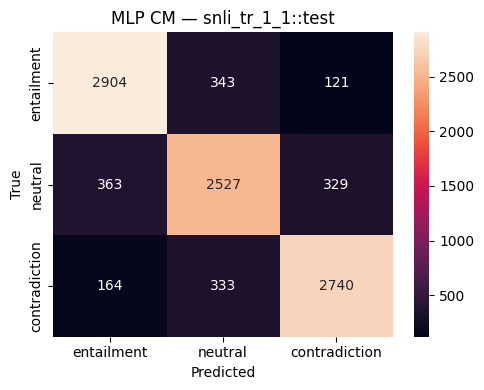

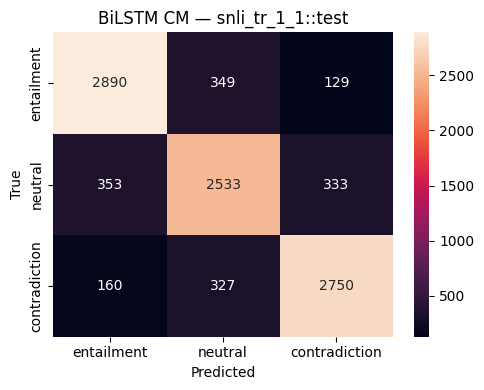

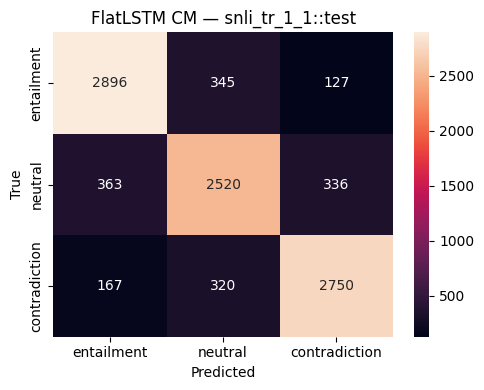


Config: multinli_tr_1_1
  Loaded multinli_tr_1_1/train — shapes: {'bert': (392599, 3), 'mdeberta': (392599, 3), 'qwen': (392599, 3)}
  Train feature shape: (392599, 21)  (expected (N, 21))
MLP epoch 01/40 | train_loss=0.6356  val_loss=0.6153
MLP epoch 02/40 | train_loss=0.6258  val_loss=0.6131
MLP epoch 03/40 | train_loss=0.6229  val_loss=0.6105
MLP epoch 04/40 | train_loss=0.6214  val_loss=0.6097
MLP epoch 05/40 | train_loss=0.6200  val_loss=0.6093
MLP epoch 06/40 | train_loss=0.6193  val_loss=0.6080
MLP epoch 07/40 | train_loss=0.6193  val_loss=0.6073
MLP epoch 08/40 | train_loss=0.6185  val_loss=0.6075
MLP epoch 09/40 | train_loss=0.6184  val_loss=0.6070
MLP epoch 10/40 | train_loss=0.6181  val_loss=0.6082
MLP epoch 11/40 | train_loss=0.6176  val_loss=0.6069
MLP epoch 12/40 | train_loss=0.6180  val_loss=0.6067
MLP epoch 13/40 | train_loss=0.6175  val_loss=0.6062
MLP epoch 14/40 | train_loss=0.6169  val_loss=0.6061
MLP epoch 15/40 | train_loss=0.6169  val_loss=0.6067
MLP epoch 16/40

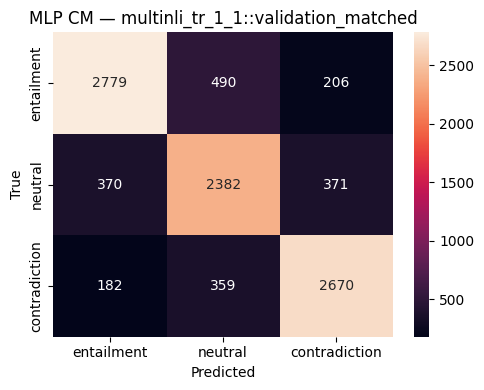

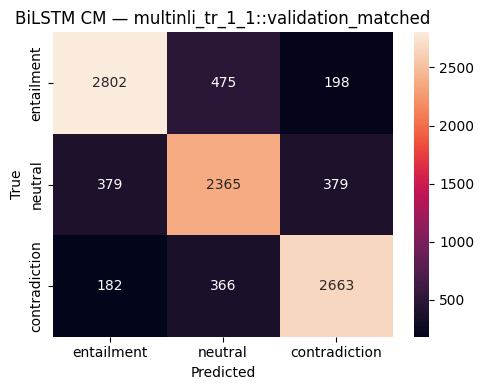

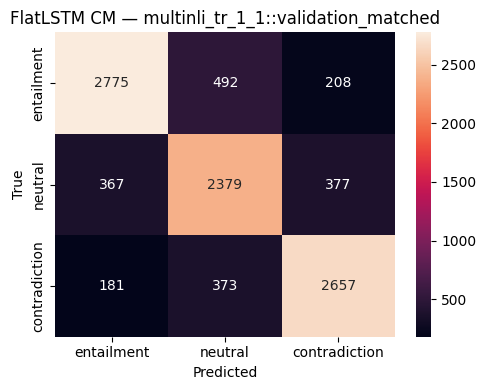

  Loaded multinli_tr_1_1/validation_mismatched — shapes: {'bert': (9825, 3), 'mdeberta': (9825, 3), 'qwen': (9825, 3)}


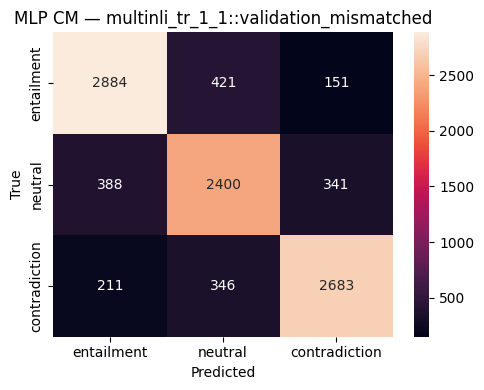

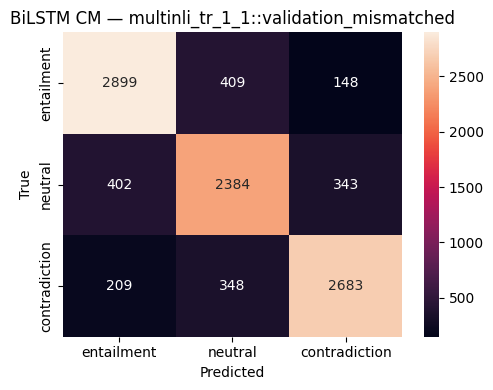

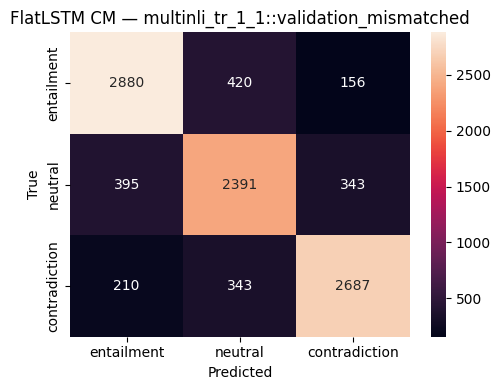


Config: trglue_mnli
  Loaded trglue_mnli/train — shapes: {'bert': (162788, 3), 'mdeberta': (162788, 3), 'qwen': (162788, 3)}
  Train feature shape: (162788, 21)  (expected (N, 21))
MLP epoch 01/40 | train_loss=0.6204  val_loss=0.5994
MLP epoch 02/40 | train_loss=0.6077  val_loss=0.5971
MLP epoch 03/40 | train_loss=0.6057  val_loss=0.5947
MLP epoch 04/40 | train_loss=0.6035  val_loss=0.5937
MLP epoch 05/40 | train_loss=0.6025  val_loss=0.5935
MLP epoch 06/40 | train_loss=0.6014  val_loss=0.5933
MLP epoch 07/40 | train_loss=0.6007  val_loss=0.5929
MLP epoch 08/40 | train_loss=0.6002  val_loss=0.5921
MLP epoch 09/40 | train_loss=0.5992  val_loss=0.5916
MLP epoch 10/40 | train_loss=0.5992  val_loss=0.5918
MLP epoch 11/40 | train_loss=0.5988  val_loss=0.5913
MLP epoch 12/40 | train_loss=0.5986  val_loss=0.5905
MLP epoch 13/40 | train_loss=0.5984  val_loss=0.5916
MLP epoch 14/40 | train_loss=0.5976  val_loss=0.5900
MLP epoch 15/40 | train_loss=0.5976  val_loss=0.5902
MLP epoch 16/40 | train

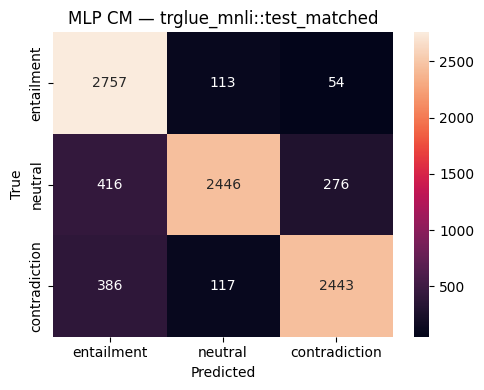

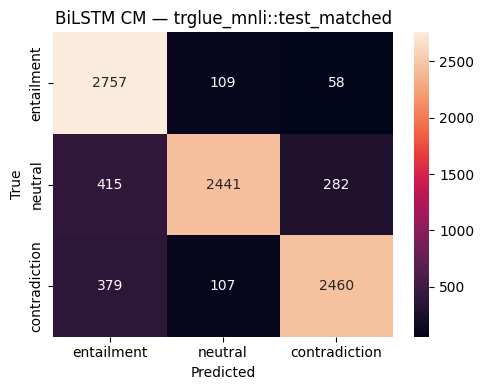

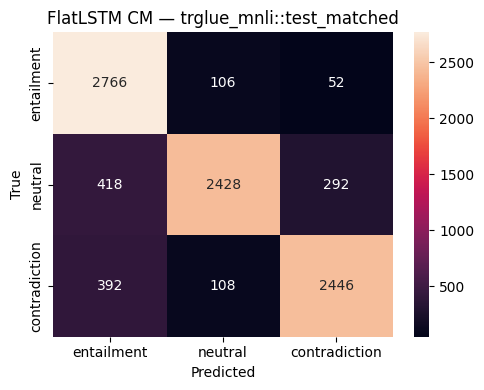

  Loaded trglue_mnli/test_mismatched — shapes: {'bert': (9217, 3), 'mdeberta': (9217, 3), 'qwen': (9217, 3)}


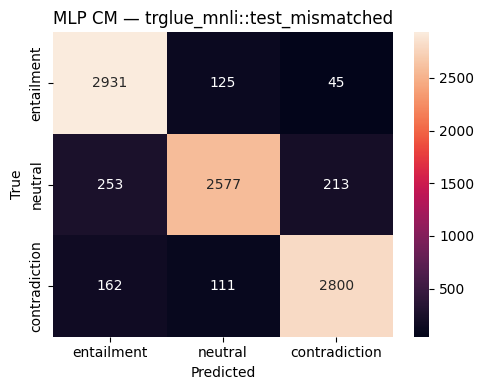

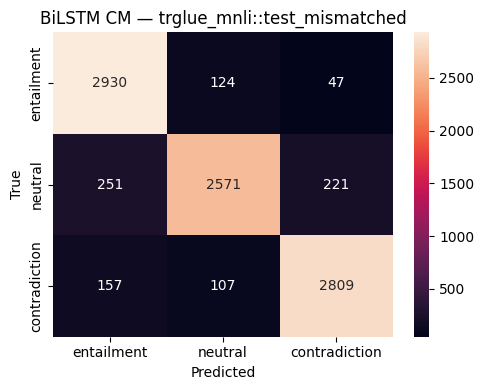

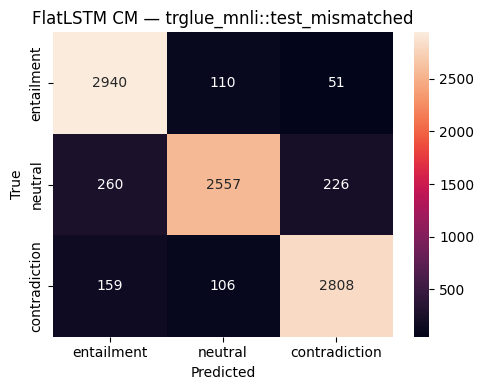

Saved: stacking_artifacts/stacking_results_jsdiv.csv


,split,method,row_kind,accuracy,f1_macro,f1_entailment,f1_neutral,f1_contradiction
10,multinli_tr_1_1::validation_matched,Meta_LinearSVC_21feat,computed,0.798960,0.798166,0.817614,0.751748,0.825136
9,multinli_tr_1_1::validation_matched,Meta_MLP_21feat,computed,0.798348,0.797759,0.816632,0.749764,0.826881
11,multinli_tr_1_1::validation_matched,Meta_BiLSTM_12feat,computed,0.798247,0.797500,0.819538,0.747353,0.825608
12,multinli_tr_1_1::validation_matched,Meta_FlatLSTM_21feat,computed,0.796310,0.795733,0.816417,0.747291,0.823493
14,multinli_tr_1_1::validation_matched,mDeBERTa,computed,0.789173,0.787688,0.808842,0.744698,0.809524
16,multinli_tr_1_1::validation_matched,Majority_vote,computed,0.770313,0.765746,0.797039,0.695176,0.805024
17,multinli_tr_1_1::validation_matched,Weighted_static,computed,0.734122,0.729956,0.768733,0.638499,0.782635
15,multinli_tr_1_1::validation_matched,Qwen,computed,0.719135,0.714753,0.757640,0.616993,0.769628
13,multinli_tr_1_1::validation_matched,BERT,computed,0.629932,0.618980,0.666667,0.514108,0.676166
18,multinli_tr_1_1::validation_mismatched,Meta_MLP_21feat,computed,0.810891,0.810037,0.831244,0.762389,0.836477


In [23]:
rows               = []
trained_meta       = {}
train_feature_bank = {}
eval_feature_bank  = {}

for cfg in CONFIGS:
    print("\n" + "="*100)
    print(f"Config: {cfg}")

    # ── Load training labels and probabilities ──
    y_train     = np.array(datasets_hf[cfg]["train"]["label"], dtype=np.int64)
    train_probs = load_probs_from_cache(cfg, "train")

    # Build 21-feature training matrix
    X_train_full = build_X(train_probs)
    print(f"  Train feature shape: {X_train_full.shape}  (expected (N, {FEATURE_DIM}))")

    # ── Train all meta-learners ──
    meta = train_meta_learners(X_train_full, train_probs, y_train)
    trained_meta[cfg] = meta
    train_feature_bank[cfg] = {
        "X_train": X_train_full,
        "y_train": y_train,
        "probs":   train_probs,
    }
    eval_feature_bank[cfg] = {}

    # ── Held-out evaluation ──
    for sp in EVAL_SPLITS[cfg]:
        split_key  = f"{cfg}::{sp}"
        y_true     = np.array(datasets_hf[cfg][sp]["label"], dtype=np.int64)
        eval_probs = load_probs_from_cache(cfg, sp)

        # Build eval features (21-dim) and scale
        X_eval_full = build_X(eval_probs)  # (N, 21)
        X_eval_s    = meta["scaler"].transform(X_eval_full).astype(np.float32)

        # BiLSTM-specific eval features (12-dim: probs + margin)
        X_eval_bilstm   = build_bilstm_input(eval_probs)  # (N, 12)
        X_eval_bilstm_s = meta["scaler_bilstm"].transform(X_eval_bilstm).astype(np.float32)

        # Store for feature importance analysis
        eval_feature_bank[cfg][sp] = {
            "X_eval_s":       X_eval_s,
            "X_eval_bilstm_s": X_eval_bilstm_s,
            "y_true":         y_true,
            "probs":          eval_probs,
        }

        # ── Meta-learner predictions ──
        pred_mlp       = _predict_batched(meta["mlp"],       X_eval_s)
        pred_bilstm    = _predict_batched(meta["bilstm"],    X_eval_bilstm_s)
        pred_flat_lstm = _predict_batched(meta["flat_lstm"], X_eval_s)
        pred_svm       = meta["svm"].predict(X_eval_s)

        # ── Individual model predictions ──
        pred_bert  = eval_probs["bert"].argmax(axis=1)
        pred_mdeb  = eval_probs["mdeberta"].argmax(axis=1)
        pred_qwen  = eval_probs["qwen"].argmax(axis=1)

        # ── Static ensemble predictions ──
        pred_majority = majority_vote_pred(eval_probs)
        pred_weighted = weighted_static_pred(eval_probs)

        # ── Record results ──
        append_row(rows, split_key, "Meta_MLP_21feat",       y_true, pred_mlp)
        append_row(rows, split_key, "Meta_LinearSVC_21feat", y_true, pred_svm)
        append_row(rows, split_key, "Meta_BiLSTM_12feat",    y_true, pred_bilstm)
        append_row(rows, split_key, "Meta_FlatLSTM_21feat",  y_true, pred_flat_lstm)
        append_row(rows, split_key, "BERT",                  y_true, pred_bert)
        append_row(rows, split_key, "mDeBERTa",              y_true, pred_mdeb)
        append_row(rows, split_key, "Qwen",                  y_true, pred_qwen)
        append_row(rows, split_key, "Majority_vote",         y_true, pred_majority)
        append_row(rows, split_key, "Weighted_static",       y_true, pred_weighted)

        # ── Confusion matrices ──
        plot_confusion(compute_metrics_dict(y_true, pred_mlp)["cm"],
                       f"MLP CM — {split_key}")
        plot_confusion(compute_metrics_dict(y_true, pred_bilstm)["cm"],
                       f"BiLSTM CM — {split_key}")
        plot_confusion(compute_metrics_dict(y_true, pred_flat_lstm)["cm"],
                       f"FlatLSTM CM — {split_key}")

results_df = pd.DataFrame(rows).sort_values(
    ["split", "row_kind", "accuracy"], ascending=[True, True, False], na_position="last"
)
out_csv = ARTIFACT_DIR / "stacking_results_jsdiv.csv"
results_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)
display(results_df)

## Styled Results Table

In [24]:
metric_cols = ["accuracy", "f1_macro", "f1_entailment", "f1_neutral", "f1_contradiction"]
pivot_df    = results_df.pivot_table(
    index=["split", "method", "row_kind"], values=metric_cols, aggfunc="first"
).reset_index()
styled = (
    pivot_df.style
    .format({m: "{:.4f}" for m in metric_cols})
    .background_gradient(subset=["accuracy", "f1_macro"], cmap="YlGn")
    .set_properties(**{"text-align": "left"})
    .set_caption(
        "Train-split-only stacking (21 features = 9 probs + 3 JS div + 3 margin + 3 var + 3 mean)"
    )
)
display(styled)

,split,method,row_kind,accuracy,f1_contradiction,f1_entailment,f1_macro,f1_neutral
0,multinli_tr_1_1::validation_matched,BERT,computed,0.6299,0.6762,0.6667,0.6190,0.5141
1,multinli_tr_1_1::validation_matched,Majority_vote,computed,0.7703,0.8050,0.7970,0.7657,0.6952
2,multinli_tr_1_1::validation_matched,Meta_BiLSTM_12feat,computed,0.7982,0.8256,0.8195,0.7975,0.7474
3,multinli_tr_1_1::validation_matched,Meta_FlatLSTM_21feat,computed,0.7963,0.8235,0.8164,0.7957,0.7473
4,multinli_tr_1_1::validation_matched,Meta_LinearSVC_21feat,computed,0.7990,0.8251,0.8176,0.7982,0.7517
5,multinli_tr_1_1::validation_matched,Meta_MLP_21feat,computed,0.7983,0.8269,0.8166,0.7978,0.7498
6,multinli_tr_1_1::validation_matched,Qwen,computed,0.7191,0.7696,0.7576,0.7148,0.6170
7,multinli_tr_1_1::validation_matched,Weighted_static,computed,0.7341,0.7826,0.7687,0.7300,0.6385
8,multinli_tr_1_1::validation_matched,mDeBERTa,computed,0.7892,0.8095,0.8088,0.7877,0.7447
9,multinli_tr_1_1::validation_mismatched,BERT,computed,0.6401,0.6961,0.6673,0.6296,0.5254


## Feature Importance Analysis

Two methods:
1. **MLP first-layer weight norms** — structural proxy (no data needed).
2. **Block permutation importance** — evaluated on **held-out eval data** (not train data).
   Blocks correspond to feature groups (probs, jsdiv, margin, variance, mean).

> **Important**: permutation importance is run on eval data because training data
> underestimates importance of features the meta-learner already memorised.

In [25]:
def _normalize_importance(vals, names):
    vals = np.array(vals, dtype=np.float64)
    s    = vals.sum()
    if s <= 0: s = 1.0
    return pd.DataFrame({"feature": names, "importance": vals / s}).sort_values(
        "importance", ascending=False
    )


def permutation_importance_blocks(
    Xs, y, predict_fn, block_defs, n_repeats=5, seed=SEED
):
    """
    Block permutation importance on held-out eval data.

    Parameters
    ----------
    Xs         : scaled feature matrix (eval set)
    y          : true labels (eval set)
    predict_fn : callable X → predictions
    block_defs : list of (name, [col_indices]) tuples
    n_repeats  : number of permutation repeats (more = more stable)
    """
    rng      = np.random.default_rng(seed)
    base_acc = accuracy_score(y, predict_fn(Xs))
    names, imps = [], []
    for name, cols in block_defs:
        names.append(name)
        drops = []
        for _ in range(n_repeats):
            Xp = Xs.copy()
            perm = rng.permutation(len(Xp))
            Xp[:, cols] = Xp[perm][:, cols]  # shuffle the block
            drops.append(base_acc - accuracy_score(y, predict_fn(Xp)))
        imps.append(float(np.mean(drops)))
    return pd.DataFrame({"feature": names, "importance": imps}).sort_values(
        "importance", ascending=False
    )


# ── Block definitions for the 21-feature vector ──
# Each block = a feature group as defined in FEAT_GROUPS.
# Permuting an entire group tells us how much that group contributes.
block_defs_full = [
    ("probs (9)",    FEAT_GROUPS["probs"]),     # cols 0-8
    ("jsdiv (3)",    FEAT_GROUPS["jsdiv"]),     # cols 9-11
    ("margin (3)",   FEAT_GROUPS["margin"]),    # cols 12-14
    ("variance (3)", FEAT_GROUPS["variance"]),  # cols 15-17
    ("mean (3)",     FEAT_GROUPS["mean"]),      # cols 18-20
]

# Per-model blocks within probs group (for finer granularity)
block_defs_per_model = [
    ("bert_probs",     [0, 1, 2]),
    ("mdeberta_probs", [3, 4, 5]),
    ("qwen_probs",     [6, 7, 8]),
]

importance_rows = []

for cfg in CONFIGS:
    # Use test_matched for trglue, else the first eval split
    eval_sp  = "test_matched" if cfg == "trglue_mnli" else EVAL_SPLITS[cfg][0]
    eb       = eval_feature_bank[cfg][eval_sp]
    X_eval_s = eb["X_eval_s"]   # (N, 21) scaled
    y_eval   = eb["y_true"]

    print("\n" + "#"*90)
    print(f"Feature importance for: {cfg}  (eval split: {eval_sp}, n={len(y_eval)})")

    meta = trained_meta[cfg]

    predict_mlp = lambda X: _predict_batched(meta["mlp"], X)

    # ── MLP first-layer weight norms (structural proxy) ──
    mlp_w      = meta["mlp"].net[0].weight.detach().cpu().numpy()  # (64, 21)
    mlp_scores = np.linalg.norm(mlp_w, axis=0)  # (21,) — L2 norm per feature
    print("\nMLP first-layer feature norms (normalized):")
    mlp_norm_df = _normalize_importance(mlp_scores, FEATURE_NAMES)
    display(mlp_norm_df)

    # ── MLP group permutation importance (eval data) ──
    print("MLP group permutation importance (eval data):")
    mlp_perm_df = permutation_importance_blocks(X_eval_s, y_eval, predict_mlp, block_defs_full)
    display(mlp_perm_df)

    # ── Per-model permutation (within probs group) ──
    print("MLP per-model permutation importance (probs group only):")
    mlp_model_perm_df = permutation_importance_blocks(
        X_eval_s, y_eval, predict_mlp, block_defs_per_model
    )
    display(mlp_model_perm_df)

    # ── LinearSVC coefficient norms ──
    svm_scores = np.linalg.norm(meta["svm"].coef_, axis=0)  # (21,)
    print("LinearSVC coefficient-norm importance (normalized):")
    svm_norm_df = _normalize_importance(svm_scores, FEATURE_NAMES)
    display(svm_norm_df)

    for df, method_name in [
        (mlp_norm_df,       "MLP_FirstLayerNorm"),
        (mlp_perm_df,       "MLP_PermutationImportance_eval"),
        (mlp_model_perm_df, "MLP_PerModel_PermImportance_eval"),
        (svm_norm_df,       "LinearSVC_CoefNorm"),
    ]:
        d = df.copy(); d["config"] = cfg; d["method"] = method_name
        importance_rows.append(d)

all_importances_df = pd.concat(importance_rows, ignore_index=True)
imp_csv = ARTIFACT_DIR / "feature_importances_jsdiv.csv"
all_importances_df.to_csv(imp_csv, index=False)
print(f"\nFeature importances saved to: {imp_csv}")


##########################################################################################
Feature importance for: snli_tr_1_1  (eval split: test, n=9824)

MLP first-layer feature norms (normalized):


,feature,importance
13,margin_mdeberta,0.119080
1,bert_p1,0.099017
14,margin_qwen,0.092273
2,bert_p2,0.064007
8,qwen_p2,0.061437
6,qwen_p0,0.056149
0,bert_p0,0.053931
12,margin_bert,0.052195
20,mean_class2,0.047267
4,mdeberta_p1,0.042365


MLP group permutation importance (eval data):


,feature,importance
0,probs (9),0.427708
4,mean (3),0.058550
3,variance (3),0.009446
1,jsdiv (3),0.007166
2,margin (3),0.006576


MLP per-model permutation importance (probs group only):


...

MLP per-model permutation importance (probs group only):


,feature,importance
1,mdeberta_probs,0.117296
2,qwen_probs,0.101488
0,bert_probs,0.015986


LinearSVC coefficient-norm importance (normalized):


,feature,importance
15,var_class0,0.077070
7,qwen_p1,0.076974
17,var_class2,0.074387
16,var_class1,0.068494
8,qwen_p2,0.067004
10,js_bert_qwen,0.066130
11,js_mdeberta_qwen,0.060718
3,mdeberta_p0,0.059913
19,mean_class1,0.057791
5,mdeberta_p2,0.055712



Feature importances saved to: stacking_artifacts/feature_importances_jsdiv.csv


## Ablation Studies

All ablations target **`trglue_mnli::test_matched`** — the hardest adversarial benchmark.

### Two types of ablations:

1. **Feature group ablations** — remove one feature group at a time from the 21-feat vector.
   Tells us which groups matter most for the MLP and LinearSVC.
   - No JS Divergence
   - No Margin
   - No Variance
   - No Mean
   - Probs only (remove all engineered features)

2. **Model ablations** — train with a subset of the 3 base models.
   - No BERT
   - No mDeBERTa
   - Only Qwen

### Design principles:
- Each ablation trains a fresh meta-learner from scratch on the ablated features.
- Evaluation is always on held-out `test_matched` data (not train data).
- MLP and BiLSTM ablations use their respective scalers fitted on the ablated features.

In [26]:
CFG_ABLATION = "trglue_mnli"
SP_ABLATION  = "test_matched"

meta_abl         = trained_meta[CFG_ABLATION]
X_train_full_abl = train_feature_bank[CFG_ABLATION]["X_train"]
y_train_abl      = train_feature_bank[CFG_ABLATION]["y_train"]
train_probs_abl  = train_feature_bank[CFG_ABLATION]["probs"]
eval_probs_abl   = eval_feature_bank[CFG_ABLATION][SP_ABLATION]["probs"]
y_true_abl       = eval_feature_bank[CFG_ABLATION][SP_ABLATION]["y_true"]

# ── Retrieve full-feature baselines from the results table ──
def _get_baseline(method_str):
    mask = (
        (results_df["split"]  == f"{CFG_ABLATION}::{SP_ABLATION}") &
        (results_df["method"] == method_str)
    )
    return float(results_df.loc[mask, "accuracy"].values[0])

baseline_mlp       = _get_baseline("Meta_MLP_21feat")
baseline_svm       = _get_baseline("Meta_LinearSVC_21feat")
baseline_bilstm    = _get_baseline("Meta_BiLSTM_12feat")
baseline_flat_lstm = _get_baseline("Meta_FlatLSTM_21feat")

print(f"Baselines on {CFG_ABLATION}::{SP_ABLATION}")
print(f"  MLP:      {baseline_mlp:.4f}")
print(f"  SVC:      {baseline_svm:.4f}")
print(f"  BiLSTM:   {baseline_bilstm:.4f}")
print(f"  FlatLSTM: {baseline_flat_lstm:.4f}")

ablation_summary = []

Baselines on trglue_mnli::test_matched
  MLP:      0.8488
  SVC:      0.8390
  BiLSTM:   0.8501
  FlatLSTM: 0.8481


In [27]:
def run_mlp_ablation(name: str, build_kwargs: dict):
    """
    Train and evaluate a fresh MLP with a subset of feature groups.

    Parameters
    ----------
    name         : experiment name
    build_kwargs : keyword arguments forwarded to build_X() to toggle groups
                   e.g. {"use_jsdiv": False} removes JS divergence features
    """
    print(f"\n{'='*70}")
    feat_names = get_feature_names_for_mask(**build_kwargs)
    print(f"MLP ablation: {name}  ({len(feat_names)} features)")

    X_tr = build_X(train_probs_abl, **build_kwargs)
    sc   = StandardScaler().fit(X_tr)
    Xs_tr = sc.transform(X_tr).astype(np.float32)

    mlp = StackingMLP(in_dim=X_tr.shape[1], n_classes=NUM_LABELS)
    mlp = _train_torch_model(mlp, Xs_tr, y_train_abl, model_name=f"MLP_{name}")

    X_ev  = build_X(eval_probs_abl, **build_kwargs)
    Xs_ev = sc.transform(X_ev).astype(np.float32)
    pred  = _predict_batched(mlp, Xs_ev)

    acc = accuracy_score(y_true_abl, pred)
    f1  = f1_score(y_true_abl, pred, average="macro", zero_division=0)
    print(f"  Acc={acc:.4f} | F1={f1:.4f} | Δ vs MLP baseline: {acc - baseline_mlp:+.4f}")
    ablation_summary.append({
        "learner": "MLP", "ablation": name, "n_features": X_tr.shape[1],
        "accuracy": acc, "f1_macro": f1, "delta_vs_baseline": acc - baseline_mlp,
    })


def run_svm_ablation(name: str, build_kwargs: dict):
    """Train and evaluate a fresh LinearSVC with a subset of feature groups."""
    print(f"\n{'='*70}")
    feat_names = get_feature_names_for_mask(**build_kwargs)
    print(f"SVM ablation: {name}  ({len(feat_names)} features)")

    X_tr  = build_X(train_probs_abl, **build_kwargs)
    sc    = StandardScaler().fit(X_tr)
    Xs_tr = sc.transform(X_tr).astype(np.float32)

    svm = LinearSVC(C=1.0, class_weight="balanced", random_state=SEED, max_iter=20000)
    svm.fit(Xs_tr, y_train_abl)

    X_ev  = build_X(eval_probs_abl, **build_kwargs)
    Xs_ev = sc.transform(X_ev).astype(np.float32)
    pred  = svm.predict(Xs_ev)

    acc = accuracy_score(y_true_abl, pred)
    f1  = f1_score(y_true_abl, pred, average="macro", zero_division=0)
    print(f"  Acc={acc:.4f} | F1={f1:.4f} | Δ vs SVM baseline: {acc - baseline_svm:+.4f}")
    ablation_summary.append({
        "learner": "SVM", "ablation": name, "n_features": X_tr.shape[1],
        "accuracy": acc, "f1_macro": f1, "delta_vs_baseline": acc - baseline_svm,
    })


def run_bilstm_model_ablation(name: str, model_keys: list):
    """
    Train and evaluate a reduced BiLSTM with a subset of models.
    Uses build_bilstm_input_reduced() — safe for .view(batch, num_models, 4).
    """
    print(f"\n{'='*70}")
    print(f"BiLSTM model ablation: {name}  (models: {model_keys})")
    num_models = len(model_keys)

    X_tr  = build_bilstm_input_reduced(train_probs_abl, model_keys)
    sc    = StandardScaler().fit(X_tr)
    Xs_tr = sc.transform(X_tr).astype(np.float32)

    bilstm = StackingBiLSTM_dynamic(num_models=num_models, features_per_model=4)
    bilstm = _train_torch_model(bilstm, Xs_tr, y_train_abl, model_name=f"BiLSTM_{name}")

    X_ev  = build_bilstm_input_reduced(eval_probs_abl, model_keys)
    Xs_ev = sc.transform(X_ev).astype(np.float32)
    pred  = _predict_batched(bilstm, Xs_ev)

    acc = accuracy_score(y_true_abl, pred)
    f1  = f1_score(y_true_abl, pred, average="macro", zero_division=0)
    print(f"  Acc={acc:.4f} | F1={f1:.4f} | Δ vs BiLSTM baseline: {acc - baseline_bilstm:+.4f}")
    ablation_summary.append({
        "learner": "BiLSTM", "ablation": name, "n_features": X_tr.shape[1],
        "accuracy": acc, "f1_macro": f1, "delta_vs_baseline": acc - baseline_bilstm,
    })


def run_flat_lstm_ablation(name: str, build_kwargs: dict):
    """Train and evaluate a reduced FlatLSTM with a subset of feature groups."""
    print(f"\n{'='*70}")
    feat_names = get_feature_names_for_mask(**build_kwargs)
    print(f"FlatLSTM ablation: {name}  ({len(feat_names)} features)")

    X_tr  = build_X(train_probs_abl, **build_kwargs)
    sc    = StandardScaler().fit(X_tr)
    Xs_tr = sc.transform(X_tr).astype(np.float32)

    flat_lstm = StackingLSTM_flat(hidden_size=64, n_classes=NUM_LABELS)
    flat_lstm = _train_torch_model(flat_lstm, Xs_tr, y_train_abl, model_name=f"FlatLSTM_{name}")

    X_ev  = build_X(eval_probs_abl, **build_kwargs)
    Xs_ev = sc.transform(X_ev).astype(np.float32)
    pred  = _predict_batched(flat_lstm, Xs_ev)

    acc = accuracy_score(y_true_abl, pred)
    f1  = f1_score(y_true_abl, pred, average="macro", zero_division=0)
    print(f"  Acc={acc:.4f} | F1={f1:.4f} | Δ vs FlatLSTM baseline: {acc - baseline_flat_lstm:+.4f}")
    ablation_summary.append({
        "learner": "FlatLSTM", "ablation": name, "n_features": X_tr.shape[1],
        "accuracy": acc, "f1_macro": f1, "delta_vs_baseline": acc - baseline_flat_lstm,
    })

### Feature Group Ablations (MLP + SVM)

Remove one feature group at a time to see how much each group contributes.
A large negative Δ means the removed group was important.

In [28]:
# ── MLP: feature group ablations ──
# Full = baseline (already trained); ablations remove one group at a time.

run_mlp_ablation("No_JSDivergence",
    dict(use_probs=True, use_jsdiv=False, use_margin=True, use_variance=True, use_mean=True))

run_mlp_ablation("No_Margin",
    dict(use_probs=True, use_jsdiv=True, use_margin=False, use_variance=True, use_mean=True))

run_mlp_ablation("No_Variance",
    dict(use_probs=True, use_jsdiv=True, use_margin=True, use_variance=False, use_mean=True))

run_mlp_ablation("No_Mean",
    dict(use_probs=True, use_jsdiv=True, use_margin=True, use_variance=True, use_mean=False))

run_mlp_ablation("ProhsOnly_NoEngineered",
    dict(use_probs=True, use_jsdiv=False, use_margin=False, use_variance=False, use_mean=False))

run_mlp_ablation("EngineeredOnly_NoProbs",
    dict(use_probs=False, use_jsdiv=True, use_margin=True, use_variance=True, use_mean=True))

# ── SVM: same feature ablations ──
run_svm_ablation("No_JSDivergence",
    dict(use_probs=True, use_jsdiv=False, use_margin=True, use_variance=True, use_mean=True))

run_svm_ablation("No_Margin",
    dict(use_probs=True, use_jsdiv=True, use_margin=False, use_variance=True, use_mean=True))

run_svm_ablation("No_Variance",
    dict(use_probs=True, use_jsdiv=True, use_margin=True, use_variance=False, use_mean=True))

run_svm_ablation("No_Mean",
    dict(use_probs=True, use_jsdiv=True, use_margin=True, use_variance=True, use_mean=False))

run_svm_ablation("ProbsOnly_NoEngineered",
    dict(use_probs=True, use_jsdiv=False, use_margin=False, use_variance=False, use_mean=False))


MLP ablation: No_JSDivergence  (18 features)
MLP_No_JSDivergence epoch 01/40 | train_loss=0.6224  val_loss=0.5984
MLP_No_JSDivergence epoch 02/40 | train_loss=0.6078  val_loss=0.5988
MLP_No_JSDivergence epoch 03/40 | train_loss=0.6061  val_loss=0.5965
MLP_No_JSDivergence epoch 04/40 | train_loss=0.6035  val_loss=0.5940
MLP_No_JSDivergence epoch 05/40 | train_loss=0.6023  val_loss=0.5934
MLP_No_JSDivergence epoch 06/40 | train_loss=0.6015  val_loss=0.5925
MLP_No_JSDivergence epoch 07/40 | train_loss=0.6003  val_loss=0.5920
MLP_No_JSDivergence epoch 08/40 | train_loss=0.5997  val_loss=0.5912
MLP_No_JSDivergence epoch 09/40 | train_loss=0.5994  val_loss=0.5915
MLP_No_JSDivergence epoch 10/40 | train_loss=0.5987  val_loss=0.5913
MLP_No_JSDivergence epoch 11/40 | train_loss=0.5985  val_loss=0.5910
MLP_No_JSDivergence epoch 12/40 | train_loss=0.5975  val_loss=0.5905
MLP_No_JSDivergence epoch 13/40 | train_loss=0.5979  val_loss=0.5906
MLP_No_JSDivergence epoch 14/40 | train_loss=0.5974  val_

### Model Ablations (BiLSTM + MLP)

Remove one base model at a time to see how much each model contributes.

In [29]:
# ── BiLSTM: model ablations (grouped 4-feature timesteps) ──
run_bilstm_model_ablation("No_BERT",       ["mdeberta", "qwen"])
run_bilstm_model_ablation("No_mDeBERTa",   ["bert",     "qwen"])
run_bilstm_model_ablation("No_Qwen",       ["bert",     "mdeberta"])
run_bilstm_model_ablation("Only_Qwen",     ["qwen"])
run_bilstm_model_ablation("Only_mDeBERTa", ["mdeberta"])

# ── MLP: model ablations (build_X on subset of probs, all engineered features) ──
def run_mlp_model_ablation(name: str, keep_model_keys: list):
    """
    MLP model ablation: only the probs for a subset of models + shared engineered features.
    We zero out the excluded model's probs and set their margin to 0.
    Simpler than rebuilding all engineered features from scratch,
    and JS/var/mean are still computed from the full model set.

    For a fully clean ablation (excluding excluded model from JS computation),
    use a filtered probs_dict with dummy distributions for excluded models.
    """
    print(f"\n{'='*70}")
    print(f"MLP model ablation: {name}  (keep models: {keep_model_keys})")

    # Build full features, then zero out excluded model probs and margins
    excluded = [m for m in MODEL_ORDER if m not in keep_model_keys]
    model_prob_cols = {"bert": [0,1,2], "mdeberta": [3,4,5], "qwen": [6,7,8]}
    model_margin_col = {"bert": 12, "mdeberta": 13, "qwen": 14}

    X_tr_full = build_X(train_probs_abl)
    X_tr = X_tr_full.copy()
    for m in excluded:
        X_tr[:, model_prob_cols[m]] = 0.0
        X_tr[:, model_margin_col[m]] = 0.0

    sc    = StandardScaler().fit(X_tr)
    Xs_tr = sc.transform(X_tr).astype(np.float32)

    mlp = StackingMLP(in_dim=FEATURE_DIM, n_classes=NUM_LABELS)
    mlp = _train_torch_model(mlp, Xs_tr, y_train_abl, model_name=f"MLP_{name}")

    X_ev_full = build_X(eval_probs_abl)
    X_ev = X_ev_full.copy()
    for m in excluded:
        X_ev[:, model_prob_cols[m]] = 0.0
        X_ev[:, model_margin_col[m]] = 0.0

    Xs_ev = sc.transform(X_ev).astype(np.float32)
    pred  = _predict_batched(mlp, Xs_ev)

    acc = accuracy_score(y_true_abl, pred)
    f1  = f1_score(y_true_abl, pred, average="macro", zero_division=0)
    print(f"  Acc={acc:.4f} | F1={f1:.4f} | Δ vs MLP baseline: {acc - baseline_mlp:+.4f}")
    ablation_summary.append({
        "learner": "MLP", "ablation": name, "n_features": FEATURE_DIM,
        "accuracy": acc, "f1_macro": f1, "delta_vs_baseline": acc - baseline_mlp,
    })


run_mlp_model_ablation("No_BERT",       ["mdeberta", "qwen"])
run_mlp_model_ablation("No_mDeBERTa",   ["bert",     "qwen"])
run_mlp_model_ablation("No_Qwen",       ["bert",     "mdeberta"])


BiLSTM model ablation: No_BERT  (models: ['mdeberta', 'qwen'])
BiLSTM_No_BERT epoch 01/40 | train_loss=0.6258  val_loss=0.6069
BiLSTM_No_BERT epoch 02/40 | train_loss=0.6050  val_loss=0.6037
BiLSTM_No_BERT epoch 03/40 | train_loss=0.6031  val_loss=0.6027
BiLSTM_No_BERT epoch 04/40 | train_loss=0.6014  val_loss=0.6010
BiLSTM_No_BERT epoch 05/40 | train_loss=0.6002  val_loss=0.6012
BiLSTM_No_BERT epoch 06/40 | train_loss=0.5996  val_loss=0.5998
BiLSTM_No_BERT epoch 07/40 | train_loss=0.5990  val_loss=0.5991
BiLSTM_No_BERT epoch 08/40 | train_loss=0.5985  val_loss=0.5994
BiLSTM_No_BERT epoch 09/40 | train_loss=0.5981  val_loss=0.5986
BiLSTM_No_BERT epoch 10/40 | train_loss=0.5976  val_loss=0.5982
BiLSTM_No_BERT epoch 11/40 | train_loss=0.5971  val_loss=0.5985
BiLSTM_No_BERT epoch 12/40 | train_loss=0.5971  val_loss=0.5977
BiLSTM_No_BERT epoch 13/40 | train_loss=0.5967  val_loss=0.5975
BiLSTM_No_BERT epoch 14/40 | train_loss=0.5965  val_loss=0.5986
BiLSTM_No_BERT epoch 15/40 | train_loss=

### FlatLSTM Feature Group Ablations

In [30]:
run_flat_lstm_ablation("No_JSDivergence",
    dict(use_probs=True, use_jsdiv=False, use_margin=True, use_variance=True, use_mean=True))

run_flat_lstm_ablation("No_Margin",
    dict(use_probs=True, use_jsdiv=True, use_margin=False, use_variance=True, use_mean=True))

run_flat_lstm_ablation("No_Variance",
    dict(use_probs=True, use_jsdiv=True, use_margin=True, use_variance=False, use_mean=True))

run_flat_lstm_ablation("ProbsOnly",
    dict(use_probs=True, use_jsdiv=False, use_margin=False, use_variance=False, use_mean=False))


FlatLSTM ablation: No_JSDivergence  (18 features)
FlatLSTM_No_JSDivergence epoch 01/40 | train_loss=0.6296  val_loss=0.6023
FlatLSTM_No_JSDivergence epoch 02/40 | train_loss=0.5997  val_loss=0.6001
FlatLSTM_No_JSDivergence epoch 03/40 | train_loss=0.5974  val_loss=0.5987
FlatLSTM_No_JSDivergence epoch 04/40 | train_loss=0.5958  val_loss=0.5969
FlatLSTM_No_JSDivergence epoch 05/40 | train_loss=0.5943  val_loss=0.5969
FlatLSTM_No_JSDivergence epoch 06/40 | train_loss=0.5936  val_loss=0.5958
FlatLSTM_No_JSDivergence epoch 07/40 | train_loss=0.5926  val_loss=0.5949
FlatLSTM_No_JSDivergence epoch 08/40 | train_loss=0.5920  val_loss=0.5951
FlatLSTM_No_JSDivergence epoch 09/40 | train_loss=0.5915  val_loss=0.5971
FlatLSTM_No_JSDivergence epoch 10/40 | train_loss=0.5907  val_loss=0.5940
FlatLSTM_No_JSDivergence epoch 11/40 | train_loss=0.5907  val_loss=0.5935
FlatLSTM_No_JSDivergence epoch 12/40 | train_loss=0.5899  val_loss=0.5940
FlatLSTM_No_JSDivergence epoch 13/40 | train_loss=0.5898  val

### Ablation Summary Table

In [31]:
abl_df = pd.DataFrame(ablation_summary)
abl_df["baseline_acc"] = abl_df["learner"].map({
    "MLP":      baseline_mlp,
    "SVM":      baseline_svm,
    "BiLSTM":   baseline_bilstm,
    "FlatLSTM": baseline_flat_lstm,
})
abl_df = abl_df.sort_values(["learner", "accuracy"], ascending=[True, False])

display(abl_df.style
    .format({"accuracy": "{:.4f}", "f1_macro": "{:.4f}",
             "delta_vs_baseline": "{:+.4f}", "baseline_acc": "{:.4f}"})
    .background_gradient(subset=["accuracy"], cmap="YlGn")
    .background_gradient(subset=["delta_vs_baseline"], cmap="RdYlGn")
    .set_caption(f"Ablation results on {CFG_ABLATION}::{SP_ABLATION}"))

abl_csv = ARTIFACT_DIR / "ablation_summary_jsdiv.csv"
abl_df.to_csv(abl_csv, index=False)
print("Saved:", abl_csv)

,learner,ablation,n_features,accuracy,f1_macro,delta_vs_baseline,baseline_acc
11,BiLSTM,No_BERT,8,0.8459,0.8457,-0.0042,0.8501
12,BiLSTM,No_mDeBERTa,8,0.8321,0.8322,-0.0180,0.8501
14,BiLSTM,Only_Qwen,4,0.8238,0.8236,-0.0263,0.8501
13,BiLSTM,No_Qwen,8,0.8232,0.8227,-0.0270,0.8501
15,BiLSTM,Only_mDeBERTa,4,0.8171,0.8160,-0.0331,0.8501
22,FlatLSTM,ProbsOnly,9,0.8489,0.8489,+0.0008,0.8481
21,FlatLSTM,No_Variance,18,0.8472,0.8471,-0.0009,0.8481
19,FlatLSTM,No_JSDivergence,18,0.8468,0.8467,-0.0013,0.8481
20,FlatLSTM,No_Margin,18,0.8458,0.8457,-0.0023,0.8481
3,MLP,No_Mean,18,0.8497,0.8496,+0.0009,0.8488


Saved: stacking_artifacts/ablation_summary_jsdiv.csv


### Ablation Bar Plot

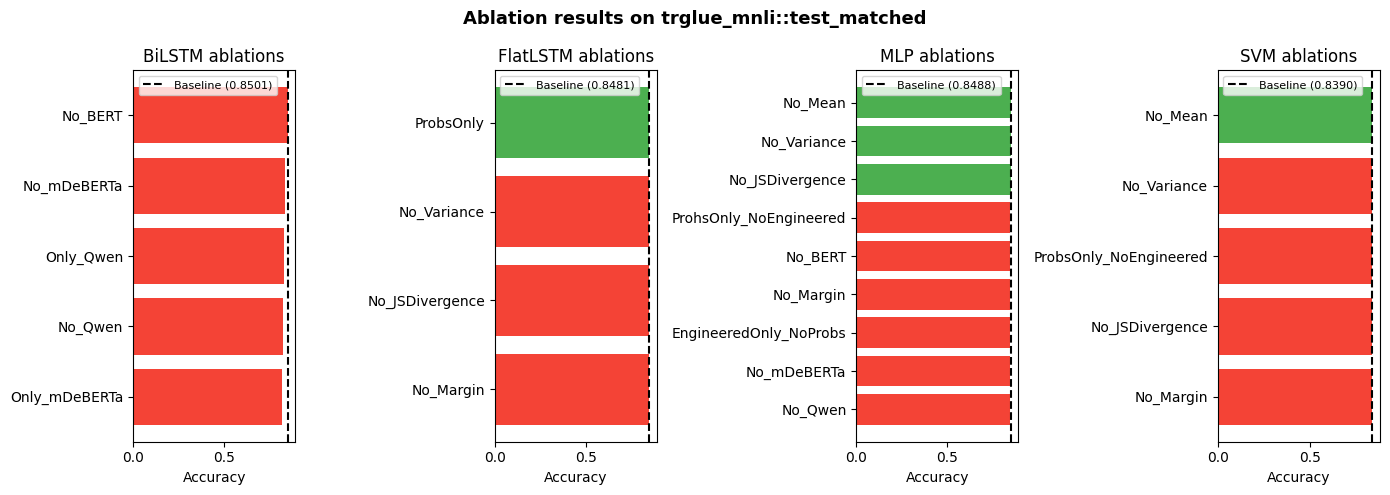

Plot saved.


In [32]:
fig, axes = plt.subplots(1, len(abl_df["learner"].unique()), figsize=(14, 5), sharey=False)
for ax, (learner, grp) in zip(axes, abl_df.groupby("learner")):
    grp = grp.sort_values("accuracy", ascending=True)
    colors = ["#4CAF50" if d >= 0 else "#F44336" for d in grp["delta_vs_baseline"]]
    ax.barh(grp["ablation"], grp["accuracy"], color=colors)
    baseline = grp["baseline_acc"].iloc[0]
    ax.axvline(baseline, color="black", linestyle="--", linewidth=1.5, label=f"Baseline ({baseline:.4f})")
    ax.set_title(f"{learner} ablations")
    ax.set_xlabel("Accuracy")
    ax.legend(fontsize=8)
plt.suptitle(f"Ablation results on {CFG_ABLATION}::{SP_ABLATION}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "ablation_barplot_jsdiv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## Save Trained Meta-Learners

In [33]:
import shutil

models_dir = ARTIFACT_DIR / "trained_models"
models_dir.mkdir(exist_ok=True, parents=True)

for cfg, meta in trained_meta.items():
    joblib.dump(meta["scaler"],        models_dir / f"{cfg}_scaler.joblib")
    joblib.dump(meta["scaler_bilstm"], models_dir / f"{cfg}_scaler_bilstm.joblib")
    torch.save(meta["mlp"].state_dict(),       models_dir / f"{cfg}_mlp.pt")
    joblib.dump(meta["svm"],                   models_dir / f"{cfg}_svm.joblib")
    torch.save(meta["bilstm"].state_dict(),    models_dir / f"{cfg}_bilstm.pt")
    torch.save(meta["flat_lstm"].state_dict(), models_dir / f"{cfg}_flat_lstm.pt")
    print(f"Saved meta-learners for {cfg}")

# Zip all artifacts
shutil.make_archive("stacking_artifacts_jsdiv", "zip", ARTIFACT_DIR)
print("Zipped stacking_artifacts_jsdiv.zip")

Saved meta-learners for snli_tr_1_1
Saved meta-learners for multinli_tr_1_1
Saved meta-learners for trglue_mnli
Zipped stacking_artifacts_jsdiv.zip


## Discussion: Grouped BiLSTM vs Flat LSTM

### Input layout comparison

| Architecture | Input shape | Timestep semantics | Features per timestep |
|---|---|---|---|
| **StackingBiLSTM** | `(batch, 12)` → `(batch, 3, 4)` | Each timestep = one base model | `[p0, p1, p2, margin]` |
| **StackingLSTM_flat** | `(batch, 21)` → `(batch, 21, 1)` | Each timestep = one raw scalar | No grouping |
| **StackingMLP** | `(batch, 21)` | N/A (no sequence) | All 21 at once |

### Why the BiLSTM uses only 12 features

JS divergence, variance, and mean are **global** features computed across all 3 models —
they cannot be cleanly assigned to a single model's timestep block.
The grouped BiLSTM processes each model as one timestep with features `[p0, p1, p2, margin]`;
including global features would require either duplicating them across timesteps (noisy)
or adding extra timesteps (breaking the model-per-timestep semantics).

The **MLP and FlatLSTM** use all 21 features, including JS, variance, and mean.

### Why JS Divergence is better than entropy here

Entropy measures a *single* model's uncertainty.
**JS Divergence** measures *disagreement between two specific models*.
A high JS(BERT, Qwen) value tells the meta-learner:
> "BERT and Qwen strongly disagree on this example — be careful."

This pairwise signal is more informative than each model's individual entropy,
because it captures the *interaction* between models rather than their individual confidence.

### Feature group summary

| Feature group | Signal type | Why useful |
|---|---|---|
| Probs (9) | Per-model class probabilities | Core soft predictions |
| JS Divergence (3) | Inter-model disagreement | High JS = conflicting models |
| Margin (3) | Per-model confidence | High margin = certain prediction |
| Variance (3) | Per-class spread | High var = models assign very different p(class) |
| Mean (3) | Ensemble soft vote | Smooth approximation to majority vote |